In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from wordcloud import WordCloud
import math
import ast
from notebook_utils import plot_histogram, plot_word_cloud
import networkx as nx
import scipy.stats as stats
import numpy as np

In [121]:
metatopics = {
    "Géographie": "Geography",
    "Eucalyptus / Propriétés Botaniques": "Eucalyptus and Botanical Properties",
    "Faune et Flore": "Fauna and Flora",
    "Malaria / Assainissement": "Malaria and Drainage",
    "Maladies": "Diseases",       
    "Médecine/Médicaments": "Medicine and Medication",
    "Propriétés Chimiques": "Chimical Properties",
    "Industrie / Production": "Industry and Manufacturing",
    "Institutions / Transport": "Institutions and Transport",
    "Description": "Descriptions",
    "Autres": "Others",
    "Erreurs": "Errors"
}

type_publication = {
    "monographie": "monograph",
    "presse généraliste": "generalist press",
    "presse spécialisée": "specialised press",
    "presse officielle": "official press",
    "annuaire": "directory"
}

place_of_publication = {
    "Paris / Île de France": "Paris",
    "France Métropolitaine": "Metropolitan France",
    "Sud de la France": "South France",
    "Afrique du Nord": "North Africa",
    "Madagascar": "Madagascar",
    "Europe": "Europe",
    "Autres": "Others"
}

In [122]:
df = pd.read_csv("../data/document_data_clean_filtered.csv")

df = df.rename(columns={"type_clean": "publication_type", "publisher_place_country": "publisher_country"})

df['topics'] = df['topics'].apply(lambda x: ast.literal_eval(x))
df['metatopics'] = df['metatopics'].apply(lambda x: ast.literal_eval(x))
df['metatopics'] = df['metatopics'].apply(lambda x: [metatopics[metatopic] for metatopic in x])
df['publication_type'] = df['publication_type'].apply(lambda x: type_publication[x])
df['publisher_country'] = df['publisher_country'].apply(lambda x: place_of_publication[x])


In [123]:
#Load topic_model
with open("saved_variables/topic_model.pkl", "rb") as fp:
    topic_model = pickle.load(fp)

with open("saved_variables/less_outliers.pkl", "rb") as fp:
    less_outliers_topics = pickle.load(fp)

In [124]:
#Load docs_text and docs_ark without having to extract them
with open("saved_variables/extracted_docs_list.pkl", "rb") as fp:
    docs_text, docs_ark = pickle.load(fp)

In [ ]:
# Load co-occurrence network
G = nx.read_gexf("saved_variables/co-occurence_network.gexf")

# 1) Synchronic analysis

## 1.1) Topics

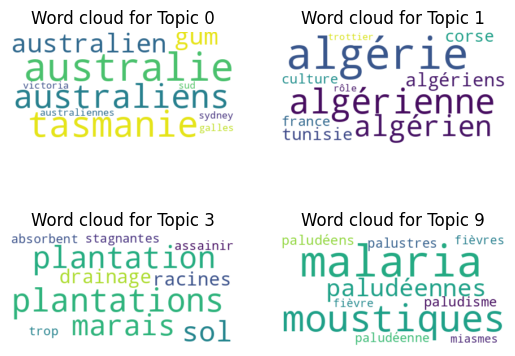

In [126]:
list_of_topics = [0,1,3,9]
fig, ax = plt.subplots(2, 2)
for i, topic in enumerate(list_of_topics):
    text = {word: value for word, value in topic_model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    ax[math.floor(i / 2)][i % 2].imshow(wc, interpolation="bilinear")
    ax[math.floor(i / 2)][i % 2].axis("off")
    ax[math.floor(i / 2)][i % 2].set_title(f"Word cloud for Topic {topic}")

plt.show()

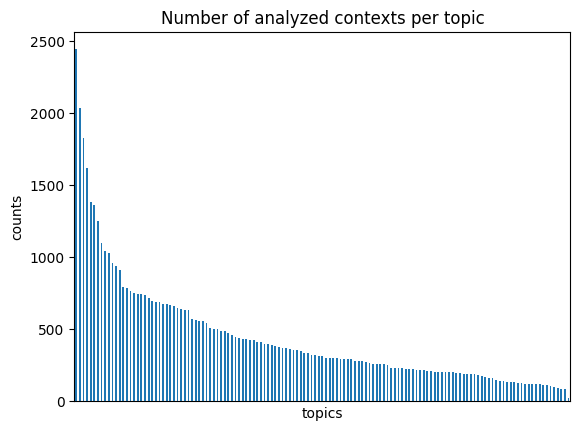

In [127]:
df_topics_exploded = df.explode("topics")
counts = df_topics_exploded["topics"].value_counts().plot(kind="bar")
plt.xticks([], [])
plt.ylabel("counts")
plt.title("Number of analyzed contexts per topic")
plt.show()

In [128]:
# Measure of how much a topic is linked with a specific location (both city and region)
topics_per_doc_list = [list(set(row["topics"])) for _, row in df.iterrows()]

general_distrib_city = df["publisher_place_clean"].value_counts(normalize=True, dropna=False).to_dict()
general_distrib_region = df["publisher_country"].value_counts(normalize=True, dropna=False).to_dict()

city_list = list(general_distrib_city.keys())
region_list = list(general_distrib_region.keys())

city_per_topic = {}
region_per_topic = {}

for topic_num in range(-1, 134):
    topic_city_data = {key: 0 for key in city_list}
    topic_region_data = {key: 0 for key in region_list}

    tot_docs = 0
    for i, doc in enumerate(topics_per_doc_list):
        if topic_num in doc:
            city = df.iloc[i]["publisher_place_clean"]
            region = df.iloc[i]["publisher_country"]
           
            topic_city_data[city] += 1
            topic_region_data[region] += 1

            tot_docs += 1

    city_per_topic[topic_num] = topic_city_data
    region_per_topic[topic_num] = topic_region_data

In [129]:
agglomeration = "city" #change variable name

topic_concentration_list = []
for topic_to_search in range(-1, 134):
    biggest_place = ("", 0)
    tot_docs = 0

    if agglomeration == "city":
        for key, item in city_per_topic[topic_to_search].items():
            if biggest_place[1] < item:
                biggest_place = (key, item)
            
            tot_docs += item
        
        chi_square_test_statistic, p_value = stats.chisquare(list(city_per_topic[topic_to_search].values()), np.array(list(general_distrib_city.values())) * tot_docs)

    elif agglomeration == "region":
        for key, item in region_per_topic[topic_to_search].items():
            if biggest_place[1] < item:
                biggest_place = (key, item)

        chi_square_test_statistic, p_value = stats.chisquare(list(region_per_topic[topic_to_search].values()), general_distrib_region)

    biggest_place = (biggest_place[0], biggest_place[1], round(biggest_place[1] / tot_docs * 100, 4))

    topic_concentration_list.append((topic_to_search, biggest_place, p_value))

sorted(topic_concentration_list, key=lambda x: x[1][2], reverse=True)


[(95, ('Paris', 109, 99.0909), np.float64(1.0)),
 (44, ('Paris', 126, 96.1832), np.float64(0.9999982571499568)),
 (117, ('Paris', 61, 95.3125), np.float64(1.0)),
 (43, ('Tananarive', 140, 95.2381), np.float64(0.0)),
 (118, ('Paris', 42, 93.3333), np.float64(1.0)),
 (61, ('Paris', 163, 91.573), np.float64(1.0)),
 (100, ('Paris', 108, 90.0), np.float64(1.0)),
 (26, ('Paris', 160, 89.8876), np.float64(1.0)),
 (35, ('Paris', 59, 89.3939), np.float64(1.0)),
 (73, ('Paris', 157, 88.2022), np.float64(0.9999999999544343)),
 (15, ('Paris', 333, 86.9452), np.float64(0.9992364987066732)),
 (84, ('Paris', 104, 86.6667), np.float64(1.0)),
 (104, ('Paris', 126, 86.3014), np.float64(1.0)),
 (74, ('Paris', 143, 86.1446), np.float64(1.0)),
 (81, ('Paris', 97, 85.0877), np.float64(1.0)),
 (22, ('Paris', 322, 84.9604), np.float64(0.30429816331151704)),
 (89, ('Paris', 225, 84.9057), np.float64(0.9930876563907167)),
 (58, ('Paris', 75, 84.2697), np.float64(1.0)),
 (80, ('Tananarive', 190, 84.0708), np.flo

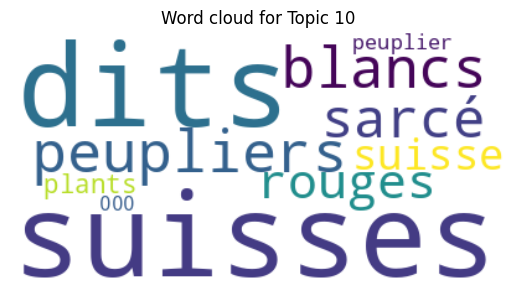

In [130]:
plot_word_cloud(10, topic_model)

In [131]:
df["publisher_place_clean"].value_counts(normalize=True)[:10]

publisher_place_clean
Paris         0.563912
Lyon          0.085528
Alger         0.079897
Tananarive    0.029800
Hyères        0.008799
Orléans       0.008389
Toulouse      0.008330
Brest         0.006629
Mende         0.006277
Lille         0.006277
Name: proportion, dtype: float64

## 1.2) Metatopics

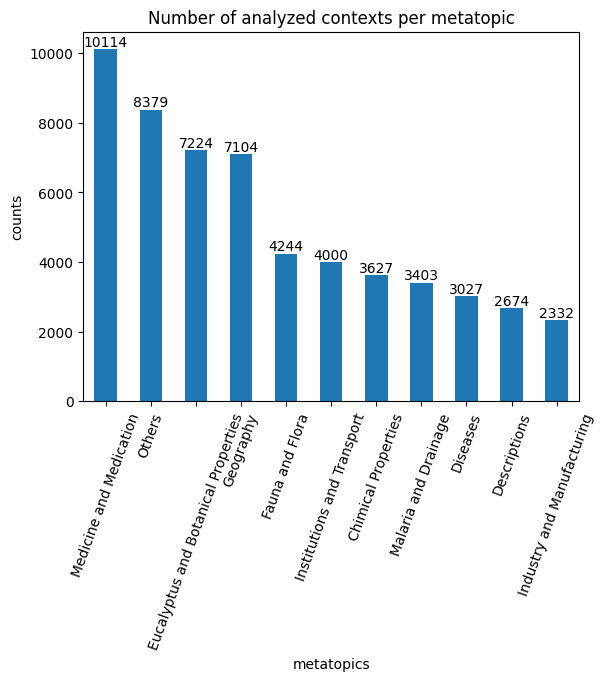

In [132]:
df_topics_exploded = df.explode("metatopics")
df_topics_exploded = df_topics_exploded[~df_topics_exploded["metatopics"].isin(["Errors"])]
ax = df_topics_exploded["metatopics"].value_counts().plot(kind="bar")
ax.bar_label(ax.containers[0])
plt.ylabel("counts")
plt.title("Number of analyzed contexts per metatopic")
plt.xticks(rotation=70)
plt.show()

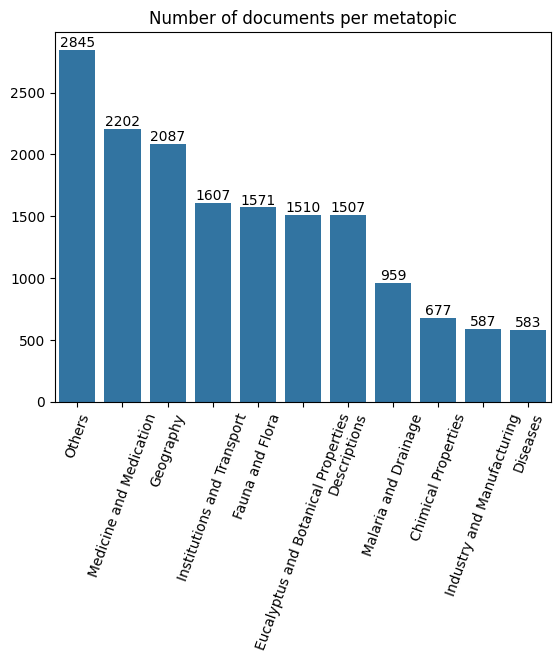

In [133]:
metatopic_count = {
    "Geography": 0,
    "Eucalyptus and Botanical Properties": 0,
    "Fauna and Flora": 0,
    "Malaria and Drainage": 0,
    "Diseases": 0,       
    "Medicine and Medication": 0,
    "Chimical Properties": 0,
    "Industry and Manufacturing": 0,
    "Institutions and Transport": 0,
    "Descriptions": 0,
    "Others": 0,
}

for i, doc in df.iterrows():
    for metatopic in doc["metatopics"]:
        if metatopic != "Errors":
            metatopic_count[metatopic] += 1 / len(doc["metatopics"])

metatopic_count = dict(sorted(metatopic_count.items(), key=lambda item: item[1], reverse=True))
metatopic_count = {k: round(v) for k, v in metatopic_count.items()}
ax = sns.barplot(metatopic_count)
ax.bar_label(ax.containers[0])
plt.title("Number of documents per metatopic")
plt.xticks(rotation=70)
plt.show()

## 1.3) Metatopics and Type of Publication

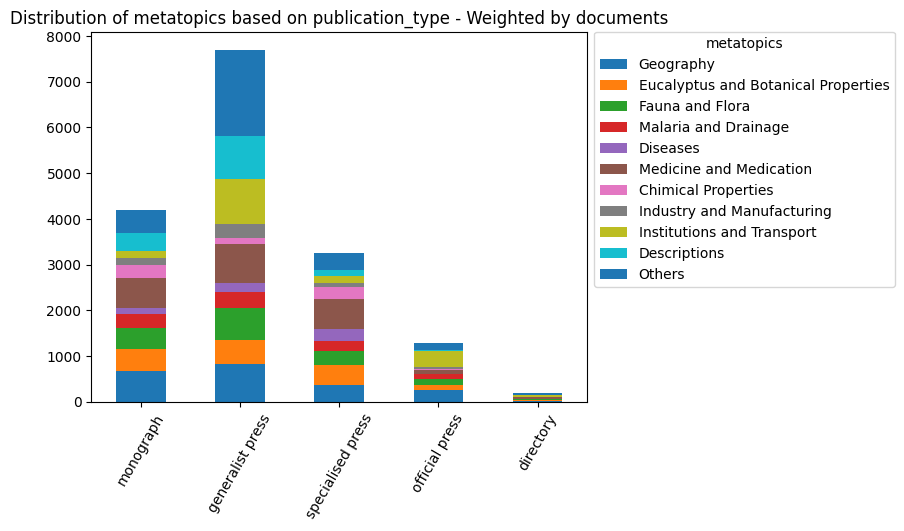

In [134]:
column_order = ['Geography', 'Eucalyptus and Botanical Properties', 'Fauna and Flora', 'Malaria and Drainage', 'Diseases', 'Medicine and Medication', 'Chimical Properties', 'Industry and Manufacturing', 'Institutions and Transport', 'Descriptions', 'Others']
row_order = ["monograph", "generalist press", "specialised press", "official press", "directory"]
plot_histogram(df, "publication_type", "metatopics", columns_to_remove=["Errors"], column_order=column_order, row_order=row_order)

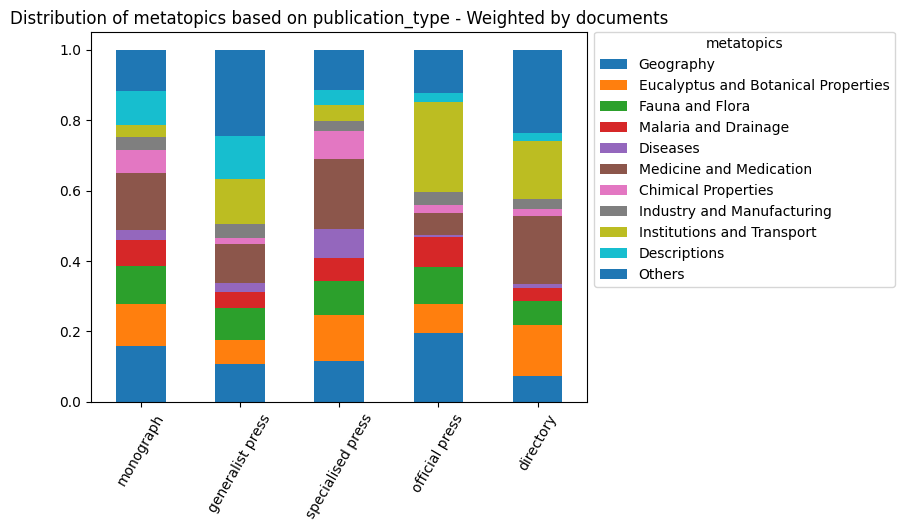

In [135]:
plot_histogram(df, "publication_type", "metatopics", columns_to_remove=["Errors"], normalize=True, column_order=column_order, row_order=row_order)

### 1.3.0) Creating dataframes for distributions within metatopics

In [136]:
topics_medicine = {
    12: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    15: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    19: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    23: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    25: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    31: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    32: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    42: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    48: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    50: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    51: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    52: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    57: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    59: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    65: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    67: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    72: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    73: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    84: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    87: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    107: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    109: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    113: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    114: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
}
df_medicine = df[df['metatopics'].apply(lambda x: "Medicine and Medication" in x)]
df_medicine["topics"] = df_medicine["topics"].apply(lambda x: [topic for topic in x if topic in topics_medicine.keys()])

for i, doc in df_medicine.iterrows():
    for topic in doc["topics"]:
        topics_medicine[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publication_type"] == "monograph":
            topics_medicine[topic]["monograph"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "generalist press":
            topics_medicine[topic]["generalist press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "specialised press":
            topics_medicine[topic]["specialised press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "official press":
            topics_medicine[topic]["official press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "directory":
            topics_medicine[topic]["directory"] += 1 / len(doc["topics"])

topics_medicine = pd.DataFrame(topics_medicine).T
topics_medicine = topics_medicine.sort_values(by="all", ascending=False)
topics_medicine["all"] = (topics_medicine["all"] / topics_medicine["all"].sum()) * 100
topics_medicine["monograph"] = (topics_medicine["monograph"] / topics_medicine["monograph"].sum()) * 100
topics_medicine["generalist press"] = (topics_medicine["generalist press"] / topics_medicine["generalist press"].sum()) * 100
topics_medicine["specialised press"] = (topics_medicine["specialised press"] / topics_medicine["specialised press"].sum()) * 100
topics_medicine["official press"] = (topics_medicine["official press"] / topics_medicine["official press"].sum()) * 100
topics_medicine["directory"] = (topics_medicine["directory"] / topics_medicine["directory"].sum()) * 100

In [137]:
topics_geography = {
    0: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    1: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    40: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    43: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    53: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    55: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    77: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    79: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    91: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    96: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
}
df_geography = df[df['metatopics'].apply(lambda x: "Geography" in x)]
df_geography["topics"] = df_geography["topics"].apply(lambda x: [topic for topic in x if topic in topics_geography.keys()])

for i, doc in df_geography.iterrows():
    for topic in doc["topics"]:
        topics_geography[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publication_type"] == "monograph":
            topics_geography[topic]["monograph"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "generalist press":
            topics_geography[topic]["generalist press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "specialised press":
            topics_geography[topic]["specialised press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "official press":
            topics_geography[topic]["official press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "directory":
            topics_geography[topic]["directory"] += 1 / len(doc["topics"])

topics_geography = pd.DataFrame(topics_geography).T
topics_geography = topics_geography.sort_values(by="all", ascending=False)
topics_geography["all"] = (topics_geography["all"] / topics_geography["all"].sum()) * 100
topics_geography["monograph"] = (topics_geography["monograph"] / topics_geography["monograph"].sum()) * 100
topics_geography["generalist press"] = (topics_geography["generalist press"] / topics_geography["generalist press"].sum()) * 100
topics_geography["specialised press"] = (topics_geography["specialised press"] / topics_geography["specialised press"].sum()) * 100
topics_geography["official press"] = (topics_geography["official press"] / topics_geography["official press"].sum()) * 100
topics_geography["directory"] = (topics_geography["directory"] / topics_geography["directory"].sum()) * 100

In [138]:
topics_institution = {
    16: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    21: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    36: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    39: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    54: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    56: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    71: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    75: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    80: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    83: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    88: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    110: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    130: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
}
df_institution = df[df['metatopics'].apply(lambda x: "Institutions and Transport" in x)]
df_institution["topics"] = df_institution["topics"].apply(lambda x: [topic for topic in x if topic in topics_institution.keys()])

for i, doc in df_institution.iterrows():
    for topic in doc["topics"]:
        topics_institution[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publication_type"] == "monograph":
            topics_institution[topic]["monograph"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "generalist press":
            topics_institution[topic]["generalist press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "specialised press":
            topics_institution[topic]["specialised press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "official press":
            topics_institution[topic]["official press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "directory":
            topics_institution[topic]["directory"] += 1 / len(doc["topics"])

topics_institution = pd.DataFrame(topics_institution).T
topics_institution = topics_institution.sort_values(by="all", ascending=False)
topics_institution["all"] = (topics_institution["all"] / topics_institution["all"].sum()) * 100
topics_institution["monograph"] = (topics_institution["monograph"] / topics_institution["monograph"].sum()) * 100
topics_institution["generalist press"] = (topics_institution["generalist press"] / topics_institution["generalist press"].sum()) * 100
topics_institution["specialised press"] = (topics_institution["specialised press"] / topics_institution["specialised press"].sum()) * 100
topics_institution["official press"] = (topics_institution["official press"] / topics_institution["official press"].sum()) * 100
topics_institution["directory"] = (topics_institution["directory"] / topics_institution["directory"].sum()) * 100

In [139]:
topics_malaria = {
    3: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    9: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    29: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
    104: {"monograph": 0, "generalist press": 0, "specialised press": 0, "official press": 0, "directory": 0, "all": 0},
}
df_malaria = df[df['metatopics'].apply(lambda x: "Malaria and Drainage" in x)]
df_malaria["topics"] = df_malaria["topics"].apply(lambda x: [topic for topic in x if topic in topics_malaria.keys()])

for i, doc in df_malaria.iterrows():
    for topic in doc["topics"]:
        topics_malaria[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publication_type"] == "monograph":
            topics_malaria[topic]["monograph"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "generalist press":
            topics_malaria[topic]["generalist press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "specialised press":
            topics_malaria[topic]["specialised press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "official press":
            topics_malaria[topic]["official press"] += 1 / len(doc["topics"])
        if doc["publication_type"] == "directory":
            topics_malaria[topic]["directory"] += 1 / len(doc["topics"])

topics_malaria = pd.DataFrame(topics_malaria).T
topics_malaria = topics_malaria.sort_values(by="all", ascending=False)
topics_malaria["all"] = (topics_malaria["all"] / topics_malaria["all"].sum()) * 100
topics_malaria["monograph"] = (topics_malaria["monograph"] / topics_malaria["monograph"].sum()) * 100
topics_malaria["generalist press"] = (topics_malaria["generalist press"] / topics_malaria["generalist press"].sum()) * 100
topics_malaria["specialised press"] = (topics_malaria["specialised press"] / topics_malaria["specialised press"].sum()) * 100
topics_malaria["official press"] = (topics_malaria["official press"] / topics_malaria["official press"].sum()) * 100
topics_malaria["directory"] = (topics_malaria["directory"] / topics_malaria["directory"].sum()) * 100

### 1.3.1) Monographs

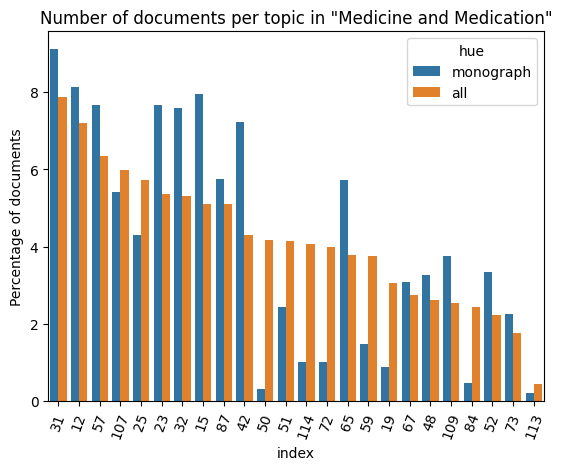

In [140]:
topics_medicine_monograph = topics_medicine.reset_index()
topics_medicine_monograph = topics_medicine_monograph.melt(
    id_vars='index',
    value_vars=["monograph", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_medicine_monograph,
    x='index',
    y='value',
    hue='hue',
    order=topics_medicine_monograph['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Medicine and Medication"')
plt.xticks(rotation=70)
plt.show()

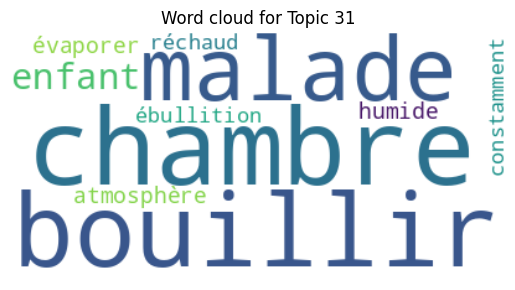

In [141]:
plot_word_cloud(31, topic_model)

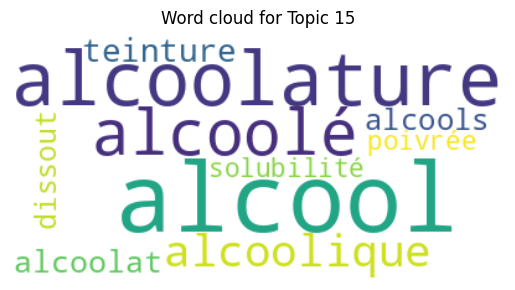

In [142]:
plot_word_cloud(15, topic_model)

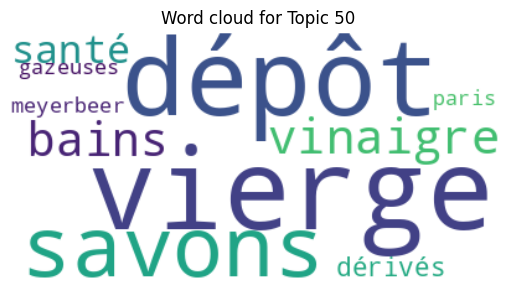

In [143]:
plot_word_cloud(50, topic_model)

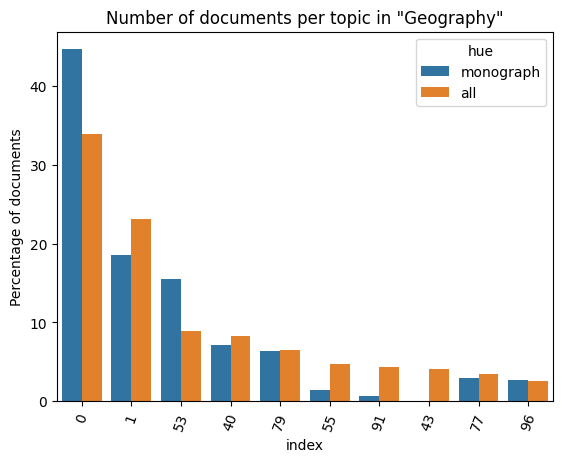

In [144]:
topics_geography_monograph = topics_geography.reset_index()
topics_geography_monograph = topics_geography_monograph.melt(
    id_vars='index',
    value_vars=["monograph", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geography_monograph,
    x='index',
    y='value',
    hue='hue',
    order=topics_geography_monograph['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

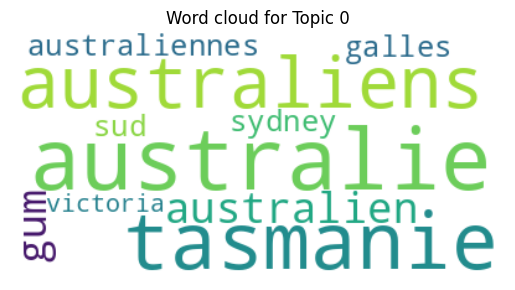

In [145]:
plot_word_cloud(0, topic_model)

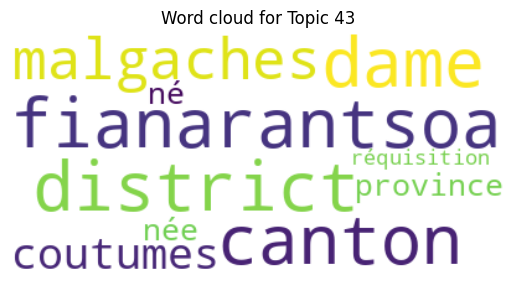

In [146]:
plot_word_cloud(43, topic_model)

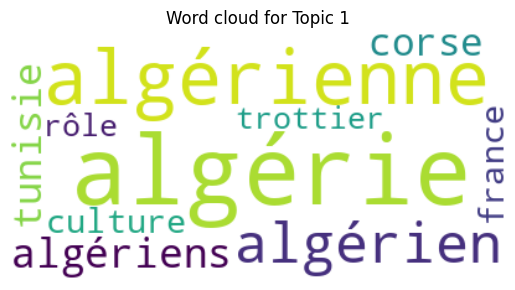

In [147]:
plot_word_cloud(1, topic_model)

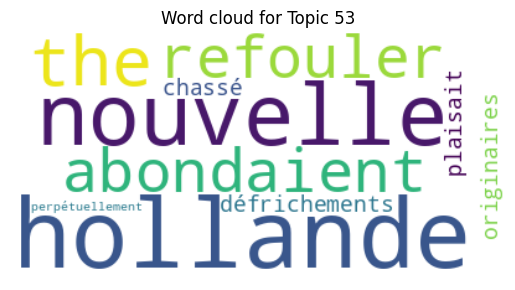

In [148]:
plot_word_cloud(53, topic_model)

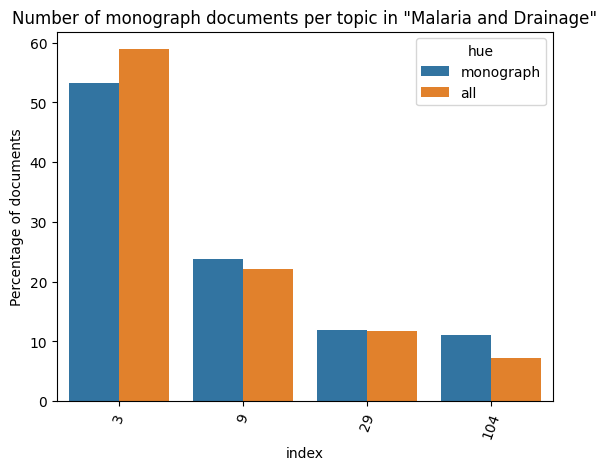

In [149]:
topics_malaria_monograph = topics_malaria.reset_index()
topics_malaria_monograph = topics_malaria_monograph.melt(
    id_vars='index',
    value_vars=["monograph", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_malaria_monograph,
    x='index',
    y='value',
    hue='hue',
    order=topics_malaria_monograph['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of monograph documents per topic in "Malaria and Drainage"')
plt.xticks(rotation=70)
plt.show()

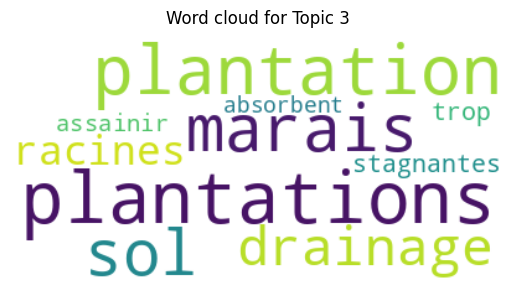

In [150]:
plot_word_cloud(3, topic_model)

### 1.3.2) Generalist press

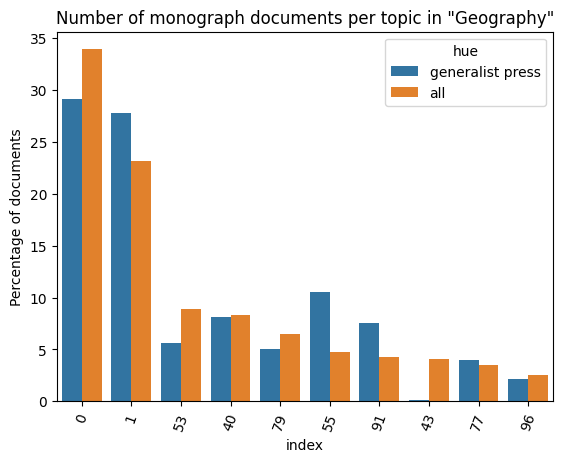

In [151]:
topics_geography_generalist = topics_geography.reset_index()
topics_geography_generalist = topics_geography_generalist.melt(
    id_vars='index',
    value_vars=["generalist press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geography_generalist,
    x='index',
    y='value',
    hue='hue',
    order=topics_geography_generalist['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of monograph documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

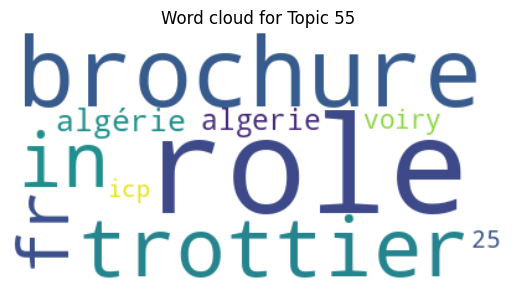

In [152]:
plot_word_cloud(55, topic_model)

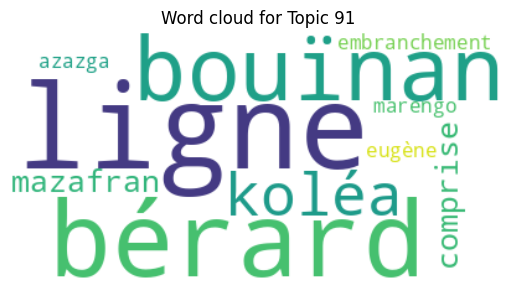

In [153]:
plot_word_cloud(91, topic_model)

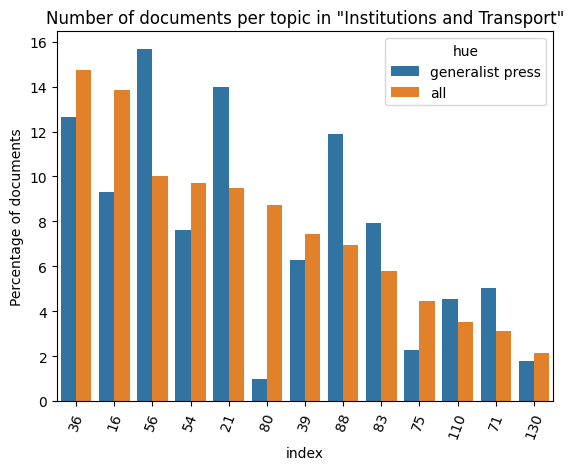

In [154]:
topics_institution_generalist = topics_institution.reset_index()
topics_institution_generalist = topics_institution_generalist.melt(
    id_vars='index',
    value_vars=["generalist press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_institution_generalist,
    x='index',
    y='value',
    hue='hue',
    order=topics_institution_generalist['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Institutions and Transport"')
plt.xticks(rotation=70)
plt.show()

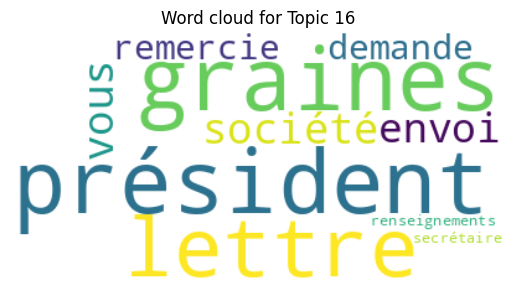

In [155]:
plot_word_cloud(16, topic_model)

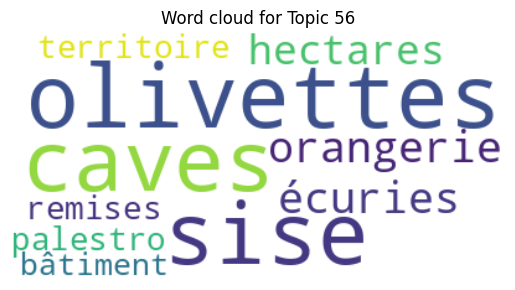

In [156]:
plot_word_cloud(56, topic_model)

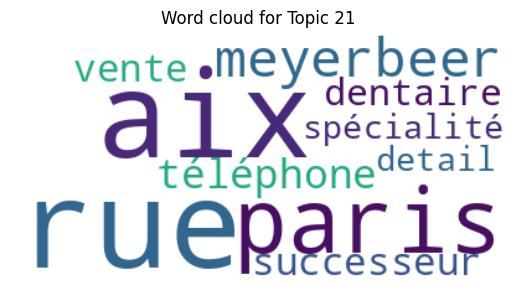

In [157]:
plot_word_cloud(21, topic_model)

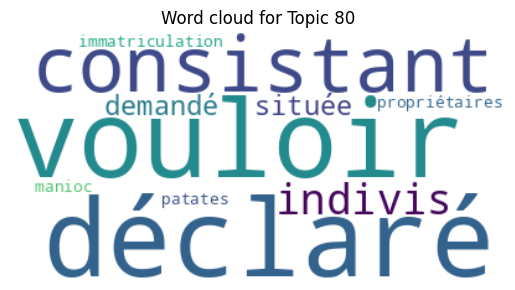

In [158]:
plot_word_cloud(80, topic_model)

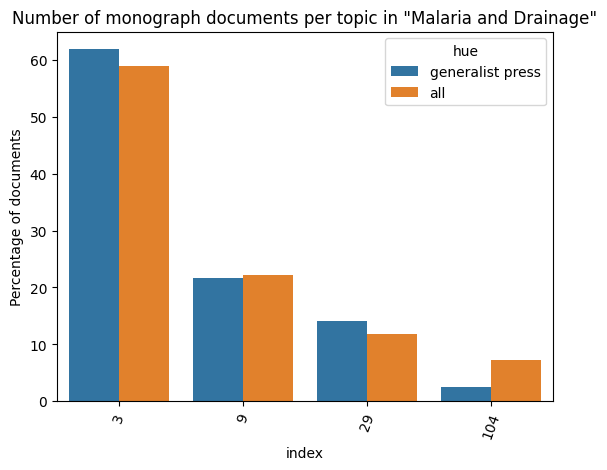

In [159]:
topics_malaria_generalist = topics_malaria.reset_index()
topics_malaria_generalist = topics_malaria_generalist.melt(
    id_vars='index',
    value_vars=["generalist press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_malaria_generalist,
    x='index',
    y='value',
    hue='hue',
    order=topics_malaria_generalist['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of monograph documents per topic in "Malaria and Drainage"')
plt.xticks(rotation=70)
plt.show()

### 1.3.3) Specialised press

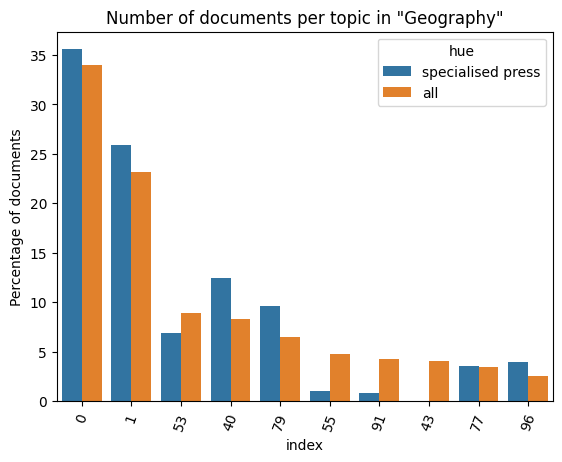

In [160]:
topics_geography_specialised = topics_geography.reset_index()
topics_geography_specialised = topics_geography_specialised.melt(
    id_vars='index',
    value_vars=["specialised press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geography_specialised,
    x='index',
    y='value',
    hue='hue',
    order=topics_geography_specialised['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

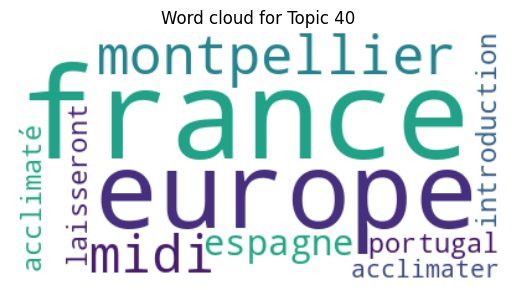

In [161]:
plot_word_cloud(40, topic_model)

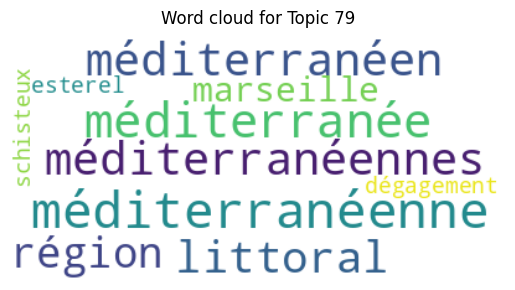

In [162]:
plot_word_cloud(79, topic_model)

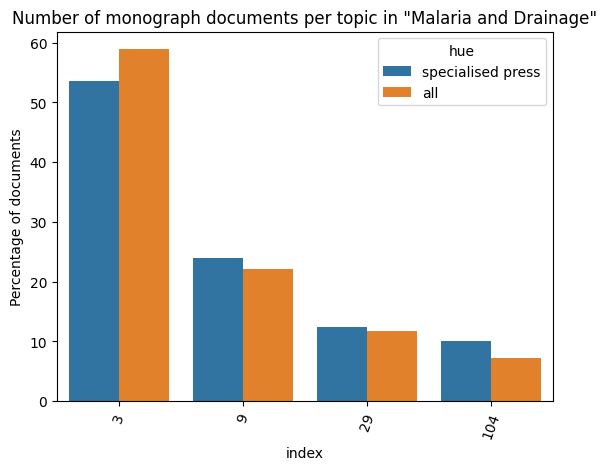

In [163]:
topics_malaria_specialised = topics_malaria.reset_index()
topics_malaria_specialised = topics_malaria_specialised.melt(
    id_vars='index',
    value_vars=["specialised press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_malaria_specialised,
    x='index',
    y='value',
    hue='hue',
    order=topics_malaria_specialised['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of monograph documents per topic in "Malaria and Drainage"')
plt.xticks(rotation=70)
plt.show()

### 1.3.4) Official press

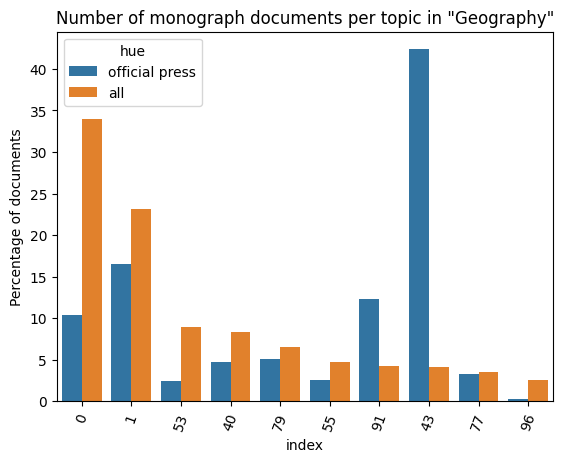

In [164]:
topics_geography_official = topics_geography.reset_index()
topics_geography_official = topics_geography_official.melt(
    id_vars='index',
    value_vars=["official press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geography_official,
    x='index',
    y='value',
    hue='hue',
    order=topics_geography_official['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of monograph documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

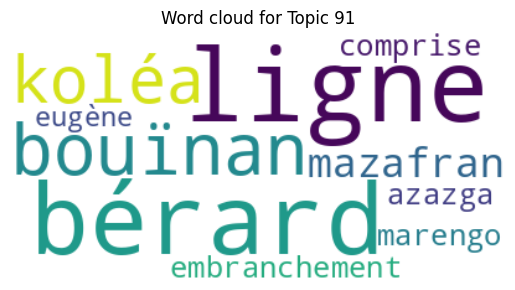

In [165]:
plot_word_cloud(91, topic_model)

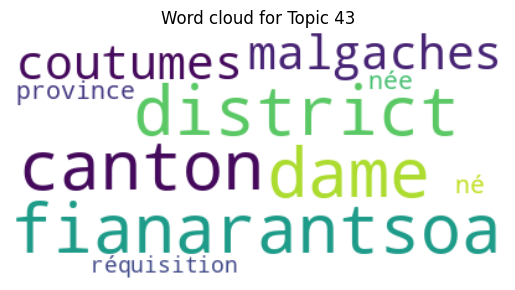

In [166]:
plot_word_cloud(43, topic_model)

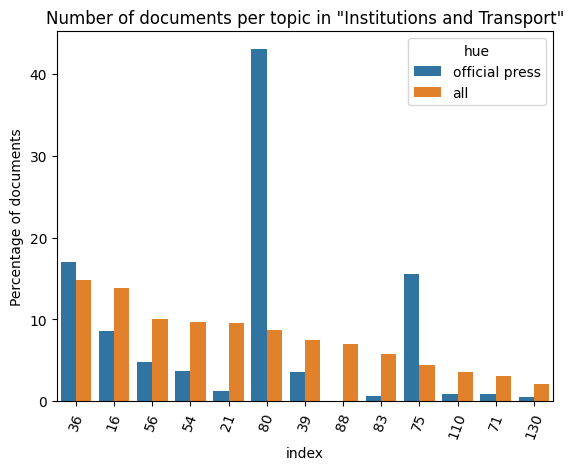

In [167]:
topics_institution_official = topics_institution.reset_index()
topics_institution_official = topics_institution_official.melt(
    id_vars='index',
    value_vars=["official press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_institution_official,
    x='index',
    y='value',
    hue='hue',
    order=topics_institution_official['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Institutions and Transport"')
plt.xticks(rotation=70)
plt.show()

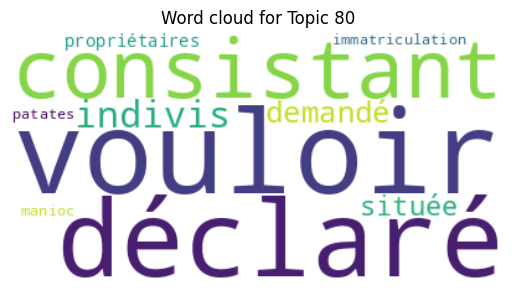

In [169]:
plot_word_cloud(80, topic_model)

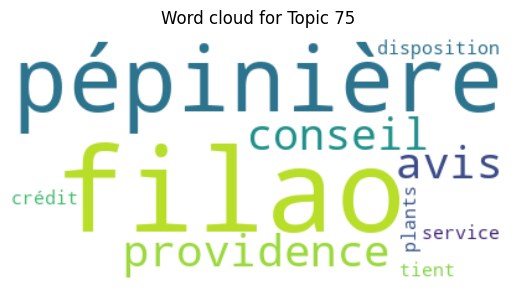

In [170]:
plot_word_cloud(75, topic_model)

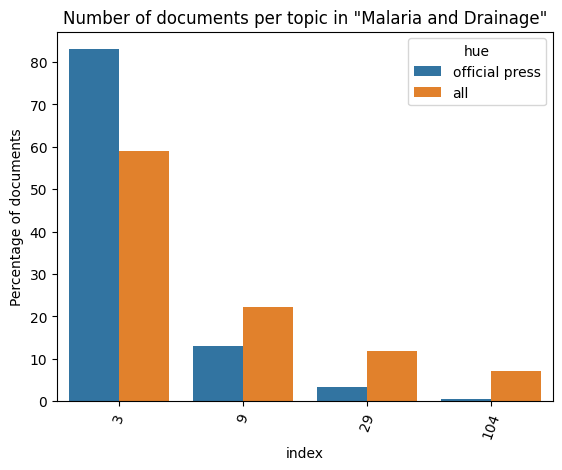

In [171]:
topics_malaria_official = topics_malaria.reset_index()
topics_malaria_official = topics_malaria_official.melt(
    id_vars='index',
    value_vars=["official press", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_malaria_official,
    x='index',
    y='value',
    hue='hue',
    order=topics_malaria_official['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Malaria and Drainage"')
plt.xticks(rotation=70)
plt.show()

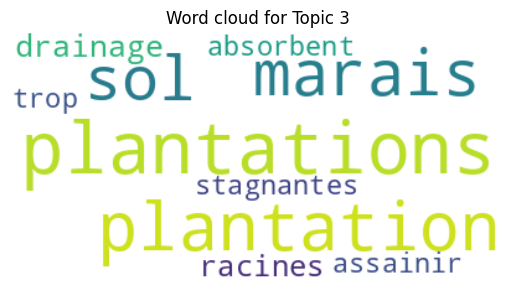

In [172]:
plot_word_cloud(3, topic_model)

## 1.4) Metatopics and place of publication:

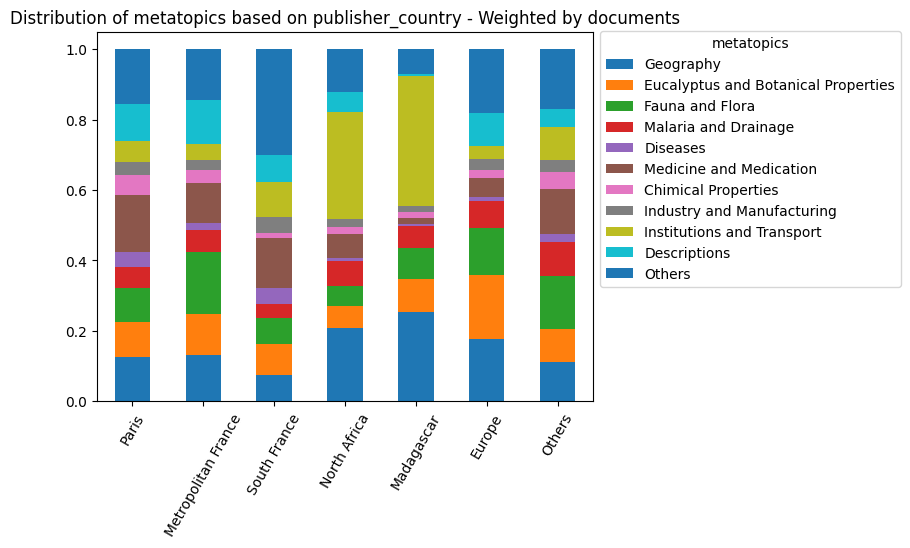

In [173]:
row_order = ["Paris", "Metropolitan France", "South France", "North Africa", "Madagascar", "Europe", "Others"]
plot_histogram(df, "publisher_country", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order, row_order=row_order)

### 1.4.0) Creating dataframes for distributions within places of publication

In [174]:
topics_geography_publication = {
    0: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    1: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    40: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    43: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    53: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    55: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    77: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    79: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    91: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    96: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
}
df_geography = df[df['metatopics'].apply(lambda x: "Geography" in x)]
df_geography["topics"] = df_geography["topics"].apply(lambda x: [topic for topic in x if topic in topics_geography_publication.keys()])

for i, doc in df_geography.iterrows():
    for topic in doc["topics"]:
        topics_geography_publication[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_country"] == "Paris":
            topics_geography_publication[topic]["Paris"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Metropolitan France":
            topics_geography_publication[topic]["Metropolitan France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "South France":
            topics_geography_publication[topic]["South France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "North Africa":
            topics_geography_publication[topic]["North Africa"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Madagascar":
            topics_geography_publication[topic]["Madagascar"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Europe":
            topics_geography_publication[topic]["Europe"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Others":
            topics_geography_publication[topic]["Others"] += 1 / len(doc["topics"])

topics_geography_publication = pd.DataFrame(topics_geography_publication).T
topics_geography_publication = topics_geography_publication.sort_values(by="all", ascending=False)
topics_geography_publication["all"] = (topics_geography_publication["all"] / topics_geography_publication["all"].sum()) * 100
topics_geography_publication["Paris"] = (topics_geography_publication["Paris"] / topics_geography_publication["Paris"].sum()) * 100
topics_geography_publication["Metropolitan France"] = (topics_geography_publication["Metropolitan France"] / topics_geography_publication["Metropolitan France"].sum()) * 100
topics_geography_publication["South France"] = (topics_geography_publication["South France"] / topics_geography_publication["South France"].sum()) * 100
topics_geography_publication["North Africa"] = (topics_geography_publication["North Africa"] / topics_geography_publication["North Africa"].sum()) * 100
topics_geography_publication["Madagascar"] = (topics_geography_publication["Madagascar"] / topics_geography_publication["Madagascar"].sum()) * 100
topics_geography_publication["Europe"] = (topics_geography_publication["Europe"] / topics_geography_publication["Europe"].sum()) * 100
topics_geography_publication["Others"] = (topics_geography_publication["Others"] / topics_geography_publication["Others"].sum()) * 100

In [175]:
fauna_publication = {
    8: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    10: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    17: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    20: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    27: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    68: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    108: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    111: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    121: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
}
df_fauna = df[df['metatopics'].apply(lambda x: "Fauna and Flora" in x)]
df_fauna["topics"] = df_fauna["topics"].apply(lambda x: [topic for topic in x if topic in fauna_publication.keys()])

for i, doc in df_fauna.iterrows():
    for topic in doc["topics"]:
        fauna_publication[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_country"] == "Paris":
            fauna_publication[topic]["Paris"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Metropolitan France":
            fauna_publication[topic]["Metropolitan France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "South France":
            fauna_publication[topic]["South France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "North Africa":
            fauna_publication[topic]["North Africa"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Madagascar":
            fauna_publication[topic]["Madagascar"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Europe":
            fauna_publication[topic]["Europe"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Others":
            fauna_publication[topic]["Others"] += 1 / len(doc["topics"])

fauna_publication = pd.DataFrame(fauna_publication).T
fauna_publication = fauna_publication.sort_values(by="all", ascending=False)
fauna_publication["all"] = (fauna_publication["all"] / fauna_publication["all"].sum()) * 100
fauna_publication["Paris"] = (fauna_publication["Paris"] / fauna_publication["Paris"].sum()) * 100
fauna_publication["Metropolitan France"] = (fauna_publication["Metropolitan France"] / fauna_publication["Metropolitan France"].sum()) * 100
fauna_publication["South France"] = (fauna_publication["South France"] / fauna_publication["South France"].sum()) * 100
fauna_publication["North Africa"] = (fauna_publication["North Africa"] / fauna_publication["North Africa"].sum()) * 100
fauna_publication["Madagascar"] = (fauna_publication["Madagascar"] / fauna_publication["Madagascar"].sum()) * 100
fauna_publication["Europe"] = (fauna_publication["Europe"] / fauna_publication["Europe"].sum()) * 100
fauna_publication["Others"] = (fauna_publication["Others"] / fauna_publication["Others"].sum()) * 100

In [176]:
topics_institution_publication = {
    16: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    21: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    36: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    39: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    54: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    56: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    71: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    75: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    80: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    83: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    88: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    110: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
    130: {"Paris": 0, "Metropolitan France": 0, "South France": 0, "North Africa": 0, "Madagascar": 0, "Europe": 0, "Others": 0, "all": 0},
}
df_institution_publication = df[df['metatopics'].apply(lambda x: "Institutions and Transport" in x)]
df_institution_publication["topics"] = df_institution_publication["topics"].apply(lambda x: [topic for topic in x if topic in topics_institution_publication.keys()])

for i, doc in df_institution_publication.iterrows():
    for topic in doc["topics"]:
        topics_institution_publication[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_country"] == "Paris":
            topics_institution_publication[topic]["Paris"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Metropolitan France":
            topics_institution_publication[topic]["Metropolitan France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "South France":
            topics_institution_publication[topic]["South France"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "North Africa":
            topics_institution_publication[topic]["North Africa"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Madagascar":
            topics_institution_publication[topic]["Madagascar"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Europe":
            topics_institution_publication[topic]["Europe"] += 1 / len(doc["topics"])
        if doc["publisher_country"] == "Others":
            topics_institution_publication[topic]["Others"] += 1 / len(doc["topics"])

topics_institution_publication = pd.DataFrame(topics_institution_publication).T
topics_institution_publication = topics_institution_publication.sort_values(by="all", ascending=False)
topics_institution_publication["all"] = (topics_institution_publication["all"] / topics_institution_publication["all"].sum()) * 100
topics_institution_publication["Paris"] = (topics_institution_publication["Paris"] / topics_institution_publication["Paris"].sum()) * 100
topics_institution_publication["Metropolitan France"] = (topics_institution_publication["Metropolitan France"] / topics_institution_publication["Metropolitan France"].sum()) * 100
topics_institution_publication["South France"] = (topics_institution_publication["South France"] / topics_institution_publication["South France"].sum()) * 100
topics_institution_publication["North Africa"] = (topics_institution_publication["North Africa"] / topics_institution_publication["North Africa"].sum()) * 100
topics_institution_publication["Madagascar"] = (topics_institution_publication["Madagascar"] / topics_institution_publication["Madagascar"].sum()) * 100
topics_institution_publication["Europe"] = (topics_institution_publication["Europe"] / topics_institution_publication["Europe"].sum()) * 100
topics_institution_publication["Others"] = (topics_institution_publication["Others"] / topics_institution_publication["Others"].sum()) * 100

### 1.4.1) Paris

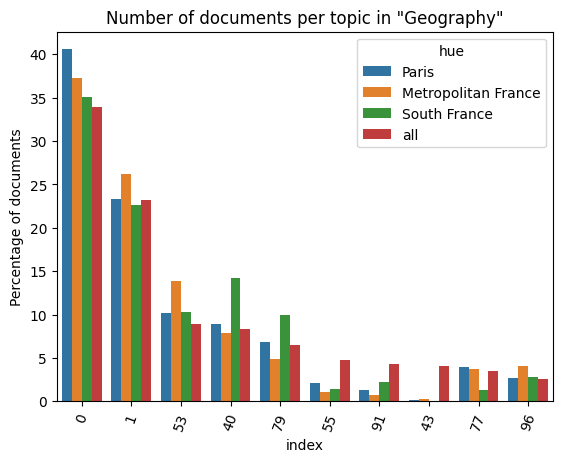

In [177]:
topics_geography_paris = topics_geography_publication.reset_index()
topics_geography_paris = topics_geography_paris.melt(
    id_vars='index',
    value_vars=["Paris", "Metropolitan France", "South France", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geography_paris,
    x='index',
    y='value',
    hue='hue',
    order=topics_geography_paris['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

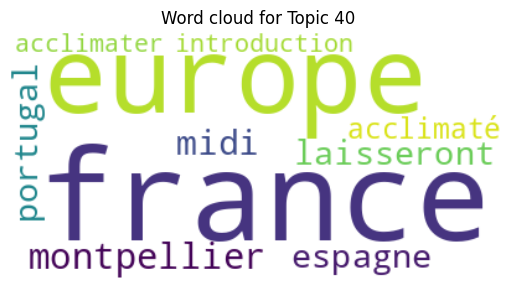

In [178]:
plot_word_cloud(40, topic_model)

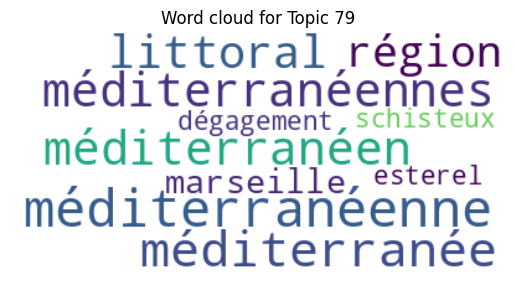

In [179]:
plot_word_cloud(79, topic_model)

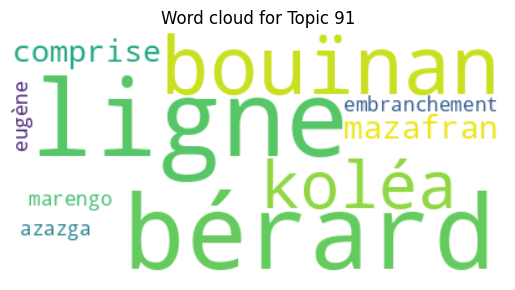

In [180]:
plot_word_cloud(91, topic_model)

### 1.4.2) Metropolitan France

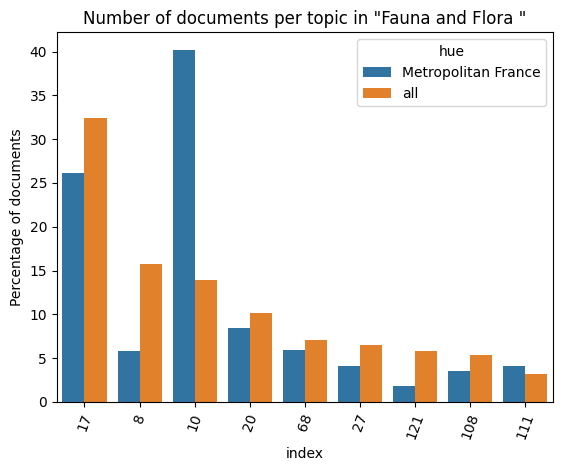

In [181]:
fauna_publication = fauna_publication.reset_index()
fauna_publication = fauna_publication.melt(
    id_vars='index',
    value_vars=["Metropolitan France", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=fauna_publication,
    x='index',
    y='value',
    hue='hue',
    order=fauna_publication['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Fauna and Flora "')
plt.xticks(rotation=70)
plt.show()

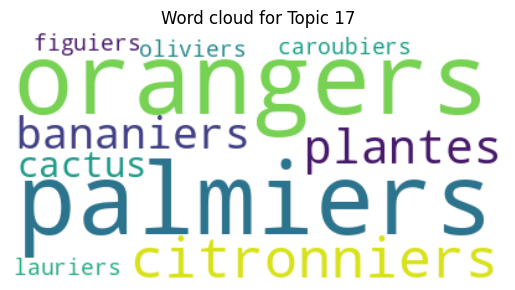

In [182]:
plot_word_cloud(17, topic_model)

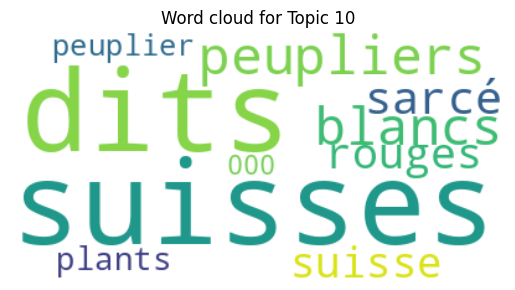

In [183]:
plot_word_cloud(10, topic_model)

### 1.4.3) South France

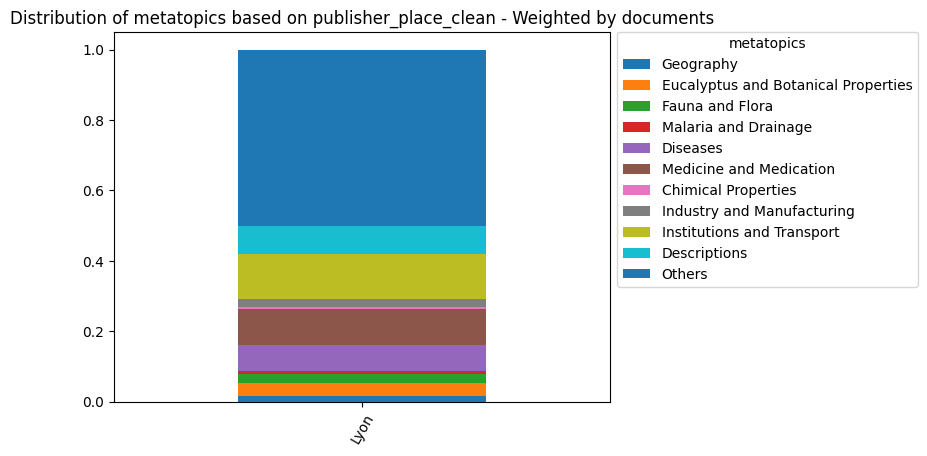

In [184]:
row_order = ["Lyon"]
df_lyon = df[df["publisher_place_clean"] == "Lyon"]
df_lyon = df_lyon[df_lyon["date_clean"] > 1900]
plot_histogram(df_lyon, "publisher_place_clean", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order, row_order=row_order)

In [185]:
topics_other_lyon = {
    -1: {"Lyon": 0, "all": 0},
    6: {"Lyon": 0, "all": 0},
    28: {"Lyon": 0, "all": 0},
    30: {"Lyon": 0, "all": 0},
    38: {"Lyon": 0, "all": 0},
    41: {"Lyon": 0, "all": 0},
    46: {"Lyon": 0, "all": 0},
    47: {"Lyon": 0, "all": 0},
    60: {"Lyon": 0, "all": 0},
    63: {"Lyon": 0, "all": 0},
    64: {"Lyon": 0, "all": 0},
    66: {"Lyon": 0, "all": 0},
    69: {"Lyon": 0, "all": 0},
    70: {"Lyon": 0, "all": 0},
    76: {"Lyon": 0, "all": 0},
    78: {"Lyon": 0, "all": 0},
    86: {"Lyon": 0, "all": 0},
    90: {"Lyon": 0, "all": 0},
    97: {"Lyon": 0, "all": 0},
    105: {"Lyon": 0, "all": 0},
    122: {"Lyon": 0, "all": 0},
    124: {"Lyon": 0, "all": 0},
    126: {"Lyon": 0, "all": 0},
    128: {"Lyon": 0, "all": 0},
    129: {"Lyon": 0, "all": 0},
}
df_other_lyon = df[df['metatopics'].apply(lambda x: "Others" in x)]
df_other_lyon["topics"] = df_other_lyon["topics"].apply(lambda x: [topic for topic in x if topic in topics_other_lyon.keys()])

for i, doc in df_other_lyon.iterrows():
    for topic in doc["topics"]:
        topics_other_lyon[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_place_clean"] == "Lyon":
            topics_other_lyon[topic]["Lyon"] += 1 / len(doc["topics"])

topics_other_lyon = pd.DataFrame(topics_other_lyon).T
topics_other_lyon = topics_other_lyon.sort_values(by="all", ascending=False)
topics_other_lyon["all"] = (topics_other_lyon["all"] / topics_other_lyon["all"].sum()) * 100
topics_other_lyon["Lyon"] = (topics_other_lyon["Lyon"] / topics_other_lyon["Lyon"].sum()) * 100

In [186]:
topics_medicine_lyon = {
    12: {"Lyon": 0, "all": 0},
    15: {"Lyon": 0, "all": 0},
    19: {"Lyon": 0, "all": 0},
    23: {"Lyon": 0, "all": 0},
    25: {"Lyon": 0, "all": 0},
    31: {"Lyon": 0, "all": 0},
    32: {"Lyon": 0, "all": 0},
    42: {"Lyon": 0, "all": 0},
    48: {"Lyon": 0, "all": 0},
    50: {"Lyon": 0, "all": 0},
    51: {"Lyon": 0, "all": 0},
    52: {"Lyon": 0, "all": 0},
    57: {"Lyon": 0, "all": 0},
    59: {"Lyon": 0, "all": 0},
    65: {"Lyon": 0, "all": 0},
    67: {"Lyon": 0, "all": 0},
    72: {"Lyon": 0, "all": 0},
    73: {"Lyon": 0, "all": 0},
    84: {"Lyon": 0, "all": 0},
    87: {"Lyon": 0, "all": 0},
    107: {"Lyon": 0, "all": 0},
    109: {"Lyon": 0, "all": 0},
    113: {"Lyon": 0, "all": 0},
    114: {"Lyon": 0, "all": 0},
}
df_medicine_lyon = df[df['metatopics'].apply(lambda x: "Medicine and Medication" in x)]
df_medicine_lyon["topics"] = df_medicine_lyon["topics"].apply(lambda x: [topic for topic in x if topic in topics_medicine_lyon.keys()])

for i, doc in df_medicine_lyon.iterrows():
    for topic in doc["topics"]:
        topics_medicine_lyon[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_place_clean"] == "Lyon":
            topics_medicine_lyon[topic]["Lyon"] += 1 / len(doc["topics"])

topics_medicine_lyon = pd.DataFrame(topics_medicine_lyon).T
topics_medicine_lyon = topics_medicine_lyon.sort_values(by="all", ascending=False)
topics_medicine_lyon["all"] = (topics_medicine_lyon["all"] / topics_medicine_lyon["all"].sum()) * 100
topics_medicine_lyon["Lyon"] = (topics_medicine_lyon["Lyon"] / topics_medicine_lyon["Lyon"].sum()) * 100

In [187]:
topics_institution_lyon = {
    16: {"Lyon": 0, "all": 0},
    21: {"Lyon": 0, "all": 0},
    36: {"Lyon": 0, "all": 0},
    39: {"Lyon": 0, "all": 0},
    54: {"Lyon": 0, "all": 0},
    56: {"Lyon": 0, "all": 0},
    71: {"Lyon": 0, "all": 0},
    75: {"Lyon": 0, "all": 0},
    80: {"Lyon": 0, "all": 0},
    50: {"Lyon": 0, "all": 0},
    83: {"Lyon": 0, "all": 0},
    88: {"Lyon": 0, "all": 0},
    110: {"Lyon": 0, "all": 0},
    130: {"Lyon": 0, "all": 0},
}
df_institution_lyon = df[df['metatopics'].apply(lambda x: "Institutions and Transport" in x)]
df_institution_lyon["topics"] = df_institution_lyon["topics"].apply(lambda x: [topic for topic in x if topic in topics_institution_lyon.keys()])

for i, doc in df_institution_lyon.iterrows():
    for topic in doc["topics"]:
        topics_institution_lyon[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_place_clean"] == "Lyon":
            topics_institution_lyon[topic]["Lyon"] += 1 / len(doc["topics"])

topics_institution_lyon = pd.DataFrame(topics_institution_lyon).T
topics_institution_lyon = topics_institution_lyon.sort_values(by="all", ascending=False)
topics_institution_lyon["all"] = (topics_institution_lyon["all"] / topics_institution_lyon["all"].sum()) * 100
topics_institution_lyon["Lyon"] = (topics_institution_lyon["Lyon"] / topics_institution_lyon["Lyon"].sum()) * 100

In [188]:
topics_all_lyon = {}
for i in range(-1, 140):
    topics_all_lyon[i] = {"Lyon": 0, "all": 0}

for i, doc in df.iterrows():
    for topic in doc["topics"]:
        topics_all_lyon[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_place_clean"] == "Lyon":
            topics_all_lyon[topic]["Lyon"] += 1 / len(doc["topics"])

topics_all_lyon = pd.DataFrame(topics_all_lyon).T
topics_all_lyon = topics_all_lyon.sort_values(by="all", ascending=False)
topics_all_lyon["all"] = (topics_all_lyon["all"] / topics_all_lyon["all"].sum()) * 100
topics_all_lyon["Lyon"] = (topics_all_lyon["Lyon"] / topics_all_lyon["Lyon"].sum()) * 100

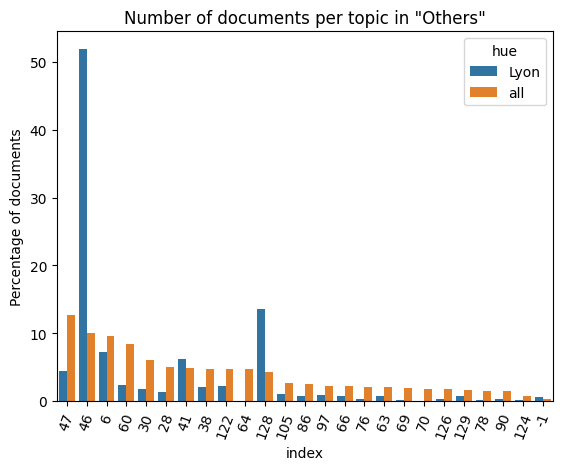

In [189]:
topics_other_lyon_plot = topics_other_lyon.reset_index()
topics_other_lyon_plot = topics_other_lyon_plot.melt(
    id_vars='index',
    value_vars=["Lyon", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_other_lyon_plot,
    x='index',
    y='value',
    hue='hue',
    order=topics_other_lyon_plot['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Others"')
plt.xticks(rotation=70)
plt.show()

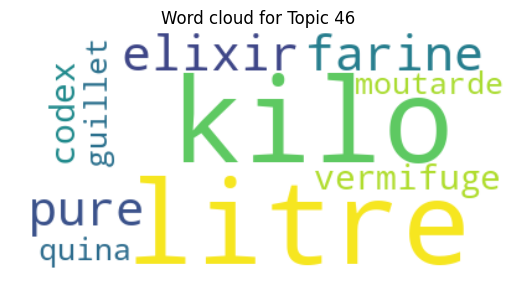

In [190]:
plot_word_cloud(46, topic_model)

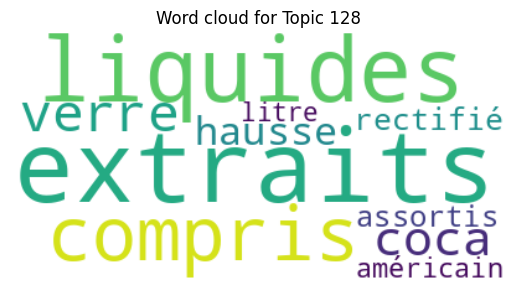

In [191]:
plot_word_cloud(128, topic_model)

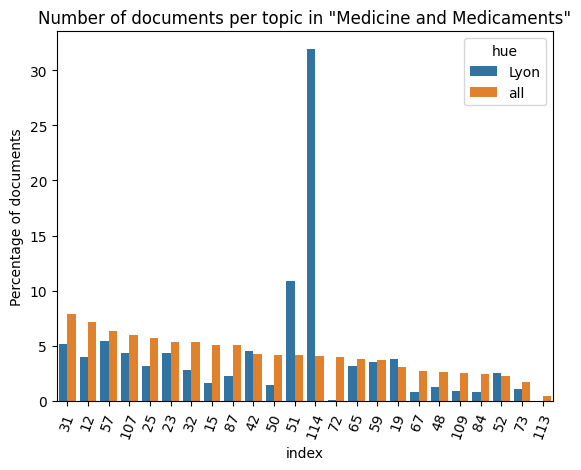

In [192]:
topics_medicine_lyon_plot = topics_medicine_lyon.reset_index()
topics_medicine_lyon_plot = topics_medicine_lyon_plot.melt(
    id_vars='index',
    value_vars=["Lyon", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_medicine_lyon_plot,
    x='index',
    y='value',
    hue='hue',
    order=topics_medicine_lyon_plot['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Medicine and Medicaments"')
plt.xticks(rotation=70)
plt.show()

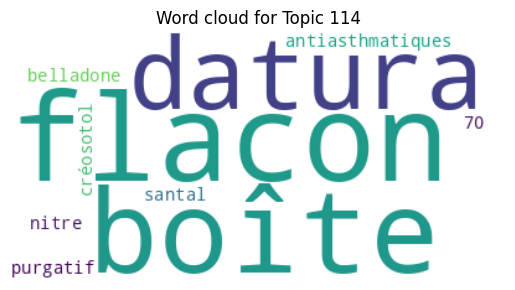

In [193]:
plot_word_cloud(114, topic_model)

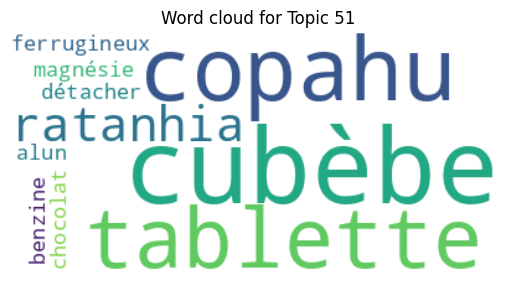

In [194]:
plot_word_cloud(51, topic_model)

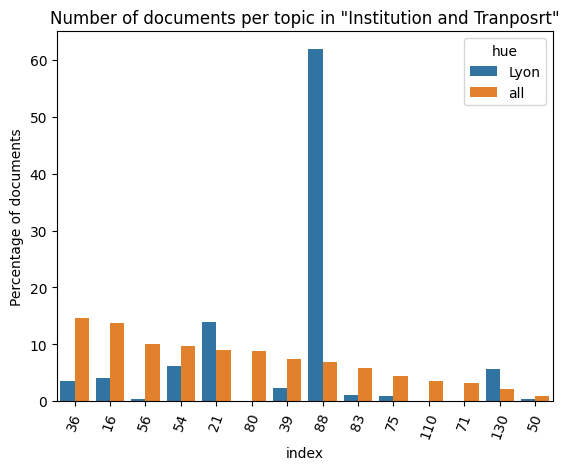

In [195]:
topics_institution_lyon_plot = topics_institution_lyon.reset_index()
topics_institution_lyon_plot = topics_institution_lyon_plot.melt(
    id_vars='index',
    value_vars=["Lyon", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_institution_lyon_plot,
    x='index',
    y='value',
    hue='hue',
    order=topics_institution_lyon_plot['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Institution and Tranposrt"')
plt.xticks(rotation=70)
plt.show()

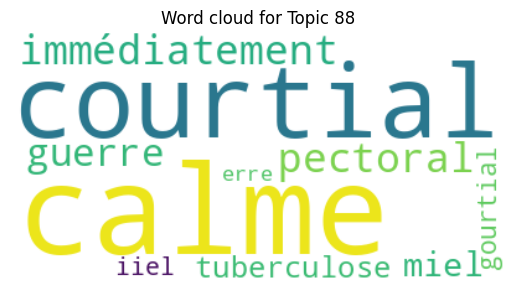

In [196]:
plot_word_cloud(88, topic_model)

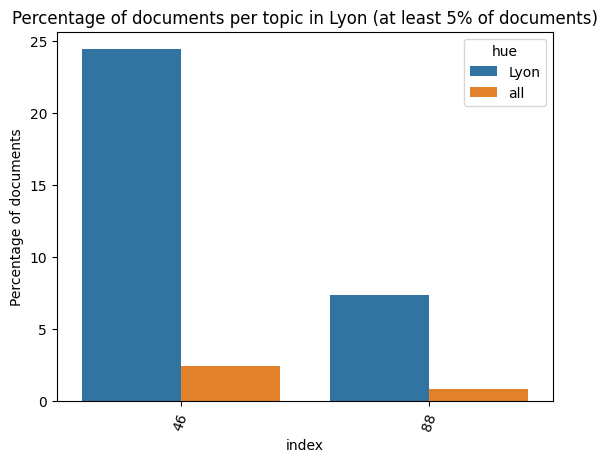

In [197]:
topics_all_lyon_plot = topics_all_lyon[topics_all_lyon["Lyon"] > 5].reset_index()
topics_all_lyon_plot = topics_all_lyon_plot.melt(
    id_vars='index',
    value_vars=["Lyon", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_all_lyon_plot,
    x='index',
    y='value',
    hue='hue',
    order=topics_all_lyon_plot['index']
)
plt.ylabel("Percentage of documents")
plt.title('Percentage of documents per topic in Lyon (at least 5% of documents)')
plt.xticks(rotation=70)
plt.show()

### 1.4.4) North Africa

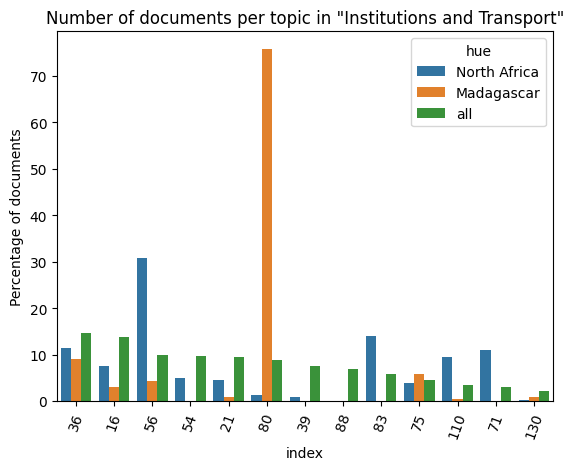

In [198]:
topics_institution_north_africa = topics_institution_publication.reset_index()
topics_institution_north_africa = topics_institution_north_africa.melt(
    id_vars='index',
    value_vars=["North Africa", "Madagascar", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_institution_north_africa,
    x='index',
    y='value',
    hue='hue',
    order=topics_institution_north_africa['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Institutions and Transport"')
plt.xticks(rotation=70)
plt.show()

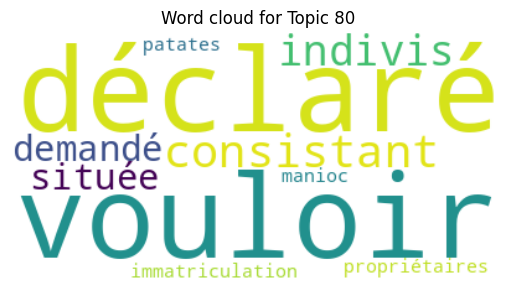

In [199]:
plot_word_cloud(80, topic_model)

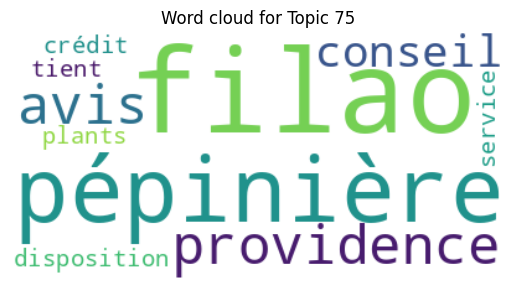

In [200]:
plot_word_cloud(75, topic_model)

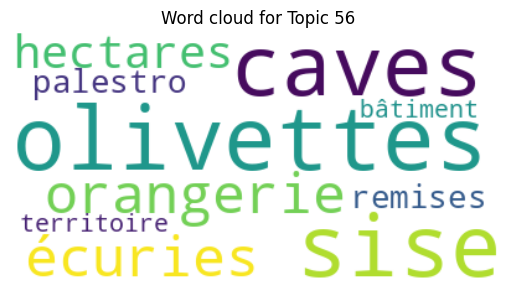

In [201]:
plot_word_cloud(56, topic_model)

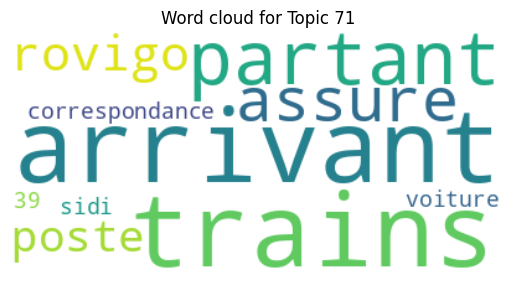

In [202]:
plot_word_cloud(71, topic_model)

### 1.4.5) Madagascar

In [203]:
df["publisher_country"].unique()

array(['Paris', 'Others', 'South France', 'North Africa',
       'Metropolitan France', 'Europe', 'Madagascar'], dtype=object)

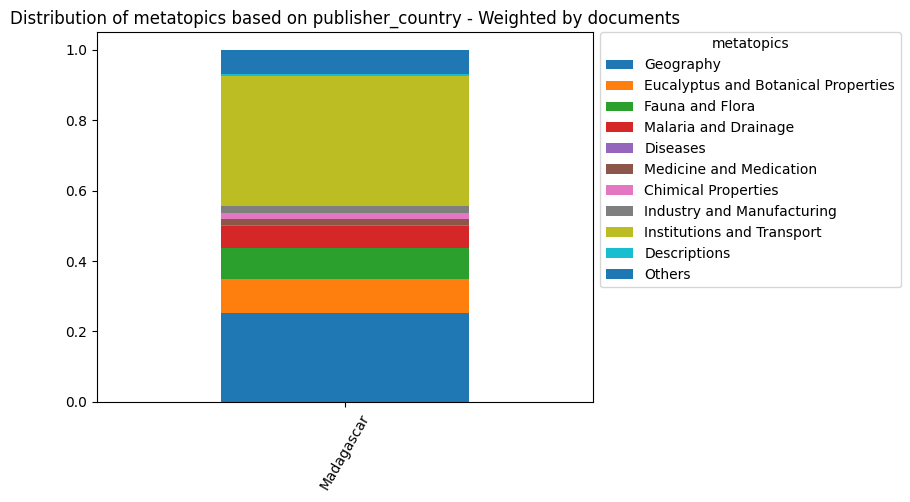

In [204]:
df_madagascar = df[df["publisher_country"] == "Madagascar"]
plot_histogram(df_madagascar, "publisher_country", "metatopics", normalize=True, columns_to_remove=["Errors"], column_order=column_order)

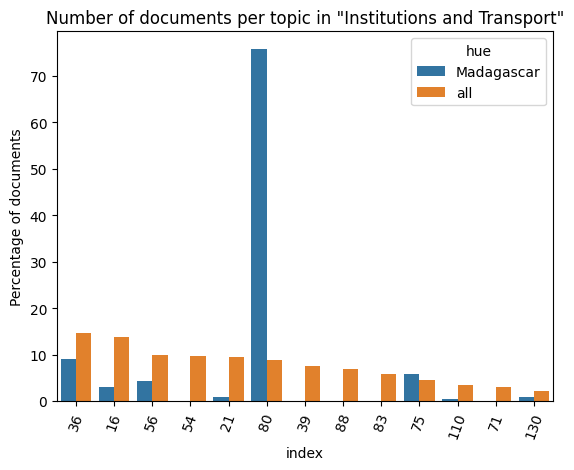

In [205]:
topics_institution_madagascar = topics_institution_publication.reset_index()
topics_institution_madagascar = topics_institution_madagascar.melt(
    id_vars='index',
    value_vars=["Madagascar", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_institution_madagascar,
    x='index',
    y='value',
    hue='hue',
    order=topics_institution_madagascar['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Institutions and Transport"')
plt.xticks(rotation=70)
plt.show()

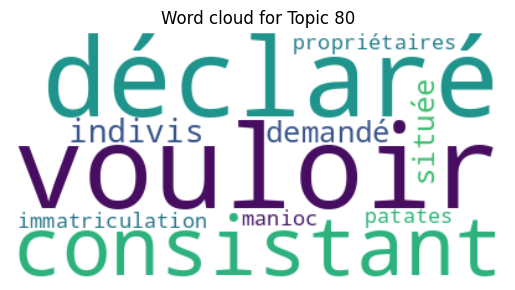

In [206]:
plot_word_cloud(80, topic_model)

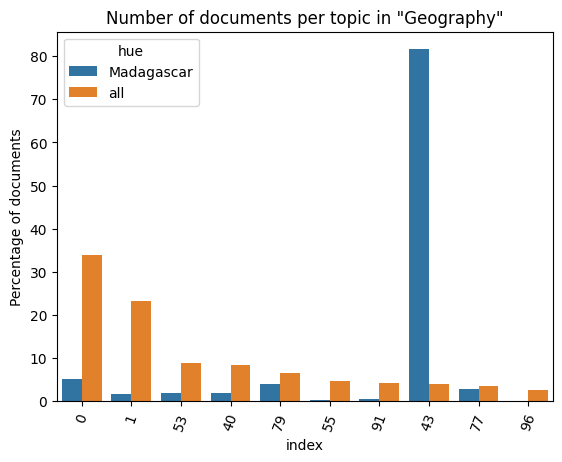

In [207]:
topics_geographie_madagascar = topics_geography_publication.reset_index()
topics_geographie_madagascar = topics_geographie_madagascar.melt(
    id_vars='index',
    value_vars=["Madagascar", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_geographie_madagascar,
    x='index',
    y='value',
    hue='hue',
    order=topics_geographie_madagascar['index']
)
plt.ylabel("Percentage of documents")
plt.title('Number of documents per topic in "Geography"')
plt.xticks(rotation=70)
plt.show()

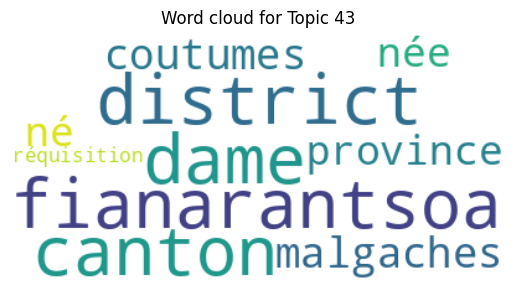

In [208]:
plot_word_cloud(43, topic_model)

In [209]:
topics_all_madagascar = {}
for i in range(-1, 140):
    topics_all_madagascar[i] = {"Madagascar": 0, "all": 0}

for i, doc in df.iterrows():
    for topic in doc["topics"]:
        topics_all_madagascar[topic]["all"] += 1 / len(doc["topics"])
        
        if doc["publisher_country"] == "Madagascar":
            topics_all_madagascar[topic]["Madagascar"] += 1 / len(doc["topics"])

topics_all_madagascar = pd.DataFrame(topics_all_madagascar).T
topics_all_madagascar = topics_all_madagascar.sort_values(by="all", ascending=False)
topics_all_madagascar["all"] = (topics_all_madagascar["all"] / topics_all_madagascar["all"].sum()) * 100
topics_all_madagascar["Madagascar"] = (topics_all_madagascar["Madagascar"] / topics_all_madagascar["Madagascar"].sum()) * 100

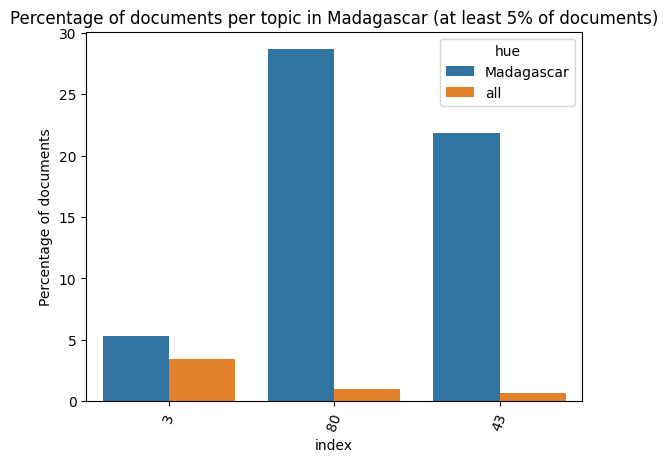

In [210]:
topics_all_madagascar_plot = topics_all_madagascar[topics_all_madagascar["Madagascar"] > 5].reset_index()
topics_all_madagascar_plot = topics_all_madagascar_plot.melt(
    id_vars='index',
    value_vars=["Madagascar", "all"],
    var_name='hue',
    value_name='value'
)

ax = sns.barplot(
    data=topics_all_madagascar_plot,
    x='index',
    y='value',
    hue='hue',
    order=topics_all_madagascar_plot['index']
)
plt.ylabel("Percentage of documents")
plt.title('Percentage of documents per topic in Madagascar (at least 5% of documents)')
plt.xticks(rotation=70)
plt.show()

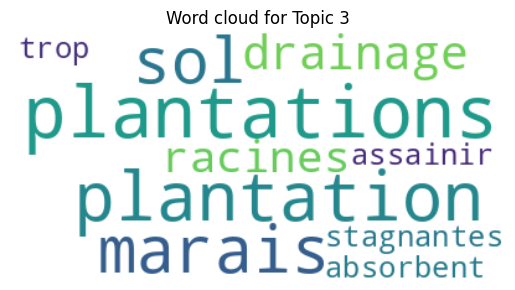

In [211]:
plot_word_cloud(3, topic_model)

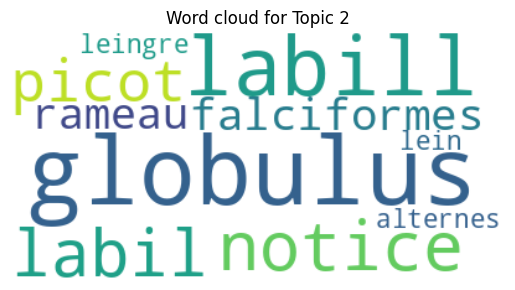

In [212]:
plot_word_cloud(2, topic_model)

In [213]:
edges=sorted(G.edges( data=True), key=lambda edge: edge[2].get('weight', 1), reverse=True)
edges

[('0', '7', {'id': '0', 'weight': 327.0}),
 ('7', '3', {'id': '1338', 'weight': 224.0}),
 ('14', '3', {'id': '1460', 'weight': 189.0}),
 ('2', '7', {'id': '1212', 'weight': 175.0}),
 ('1', '14', {'id': '139', 'weight': 163.0}),
 ('2', '11', {'id': '1213', 'weight': 150.0}),
 ('0', '79', {'id': '10', 'weight': 144.0}),
 ('14', '11', {'id': '1461', 'weight': 138.0}),
 ('2', '14', {'id': '1218', 'weight': 137.0}),
 ('14', '131', {'id': '1462', 'weight': 133.0}),
 ('79', '3', {'id': '864', 'weight': 125.0}),
 ('1', '28', {'id': '145', 'weight': 124.0}),
 ('79', '11', {'id': '865', 'weight': 122.0}),
 ('15', '6', {'id': '4882', 'weight': 121.0}),
 ('1', '79', {'id': '146', 'weight': 119.0}),
 ('3', '28', {'id': '3430', 'weight': 115.0}),
 ('0', '36', {'id': '15', 'weight': 110.0}),
 ('0', '60', {'id': '16', 'weight': 106.0}),
 ('0', '28', {'id': '18', 'weight': 102.0}),
 ('0', '122', {'id': '19', 'weight': 102.0}),
 ('79', '131', {'id': '867', 'weight': 102.0}),
 ('42', '87', {'id': '5394',

In [214]:
edges=sorted(G.edges(data=True), key=lambda edge: edge[2].get('weight', 1), reverse=True)
edges

[('0', '7', {'id': '0', 'weight': 327.0}),
 ('7', '3', {'id': '1338', 'weight': 224.0}),
 ('14', '3', {'id': '1460', 'weight': 189.0}),
 ('2', '7', {'id': '1212', 'weight': 175.0}),
 ('1', '14', {'id': '139', 'weight': 163.0}),
 ('2', '11', {'id': '1213', 'weight': 150.0}),
 ('0', '79', {'id': '10', 'weight': 144.0}),
 ('14', '11', {'id': '1461', 'weight': 138.0}),
 ('2', '14', {'id': '1218', 'weight': 137.0}),
 ('14', '131', {'id': '1462', 'weight': 133.0}),
 ('79', '3', {'id': '864', 'weight': 125.0}),
 ('1', '28', {'id': '145', 'weight': 124.0}),
 ('79', '11', {'id': '865', 'weight': 122.0}),
 ('15', '6', {'id': '4882', 'weight': 121.0}),
 ('1', '79', {'id': '146', 'weight': 119.0}),
 ('3', '28', {'id': '3430', 'weight': 115.0}),
 ('0', '36', {'id': '15', 'weight': 110.0}),
 ('0', '60', {'id': '16', 'weight': 106.0}),
 ('0', '28', {'id': '18', 'weight': 102.0}),
 ('0', '122', {'id': '19', 'weight': 102.0}),
 ('79', '131', {'id': '867', 'weight': 102.0}),
 ('42', '87', {'id': '5394',

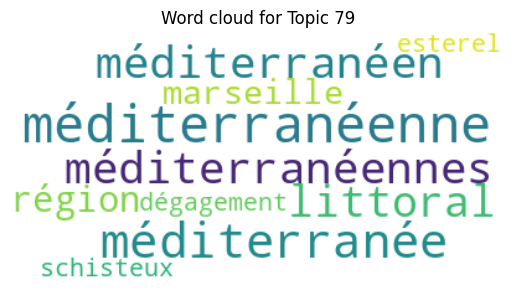

In [216]:
plot_word_cloud(79, topic_model)

# 2) Diachronic analysis

In [217]:
docs_year = [df.loc[df['ark'] == ark, "date_clean"].iloc[0] for ark in docs_ark]

In [218]:
topics_over_time = topic_model.topics_over_time(docs_text, docs_year, nr_bins=60)

In [219]:
topic_model.visualize_topics_over_time(topics_over_time, topics=[3, 43, 80])

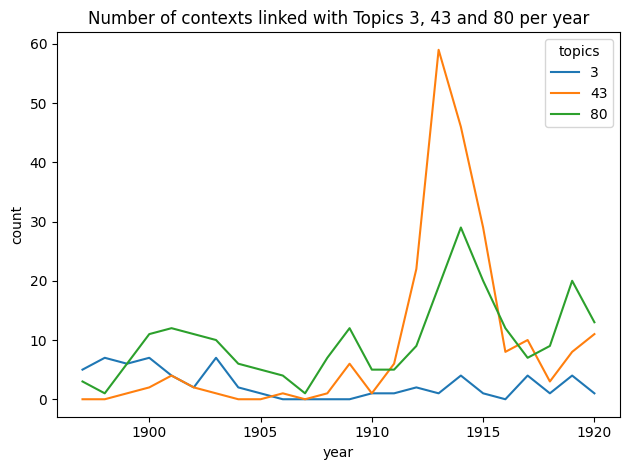

In [220]:
df_madagascar_exploded = df_madagascar.explode("topics")
df_madagascar_exploded = df_madagascar_exploded[df_madagascar_exploded["topics"].isin([3, 43, 80])]
cross_tab_madagascar_exploded = pd.crosstab(df_madagascar_exploded.date_clean, df_madagascar_exploded.topics)
sns.lineplot(cross_tab_madagascar_exploded, dashes=False)
plt.title("Number of contexts linked with Topics 3, 43 and 80 per year")
plt.ylabel("count")
plt.xlabel("year")
plt.tight_layout()

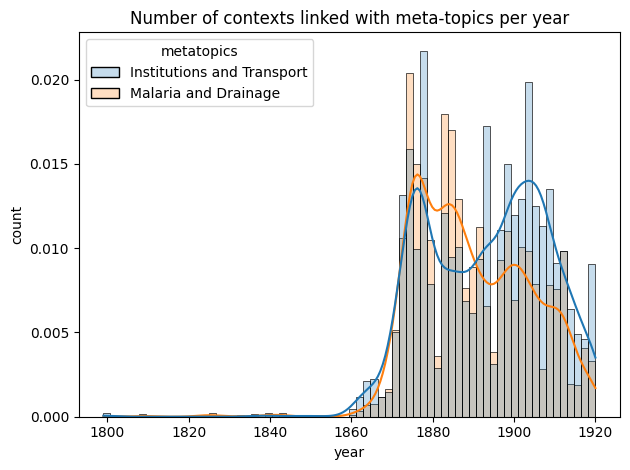

In [221]:
df_metatopics_exploded = df.explode("metatopics")
df_metatopics_exploded = df_metatopics_exploded[df_metatopics_exploded["metatopics"].isin(["Malaria and Drainage", "Institutions and Transport"])]
sns.histplot(df_metatopics_exploded, x="date_clean", hue="metatopics", kde=True, bins=70, stat="density", alpha=0.25)
plt.title("Number of contexts linked with meta-topics per year")
plt.ylabel("count")
plt.xlabel("year")
plt.tight_layout()